# EDA — Prédiction du risque d'annulation
**Maeva — Mastère DIA Paris**

Analyse exploratoire du dataset `v_dataset_annulation`.
Objectif : comprendre la structure des données, la cible, et valider les signaux clés (condition Flex, canal, engagement email) avant la modélisation.

---

## 0. Installation (une seule fois)

In [3]:
# %pip install pandas numpy matplotlib seaborn google-cloud-bigquery db-dtypes pyarrow

## 1. Imports & configuration

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

# Palette cohérente
C_ANNUL = '#e74c3c'   # annulation
C_MAINT = '#2ecc71'   # maintenu
C_BLUE  = '#3498db'
C_PURP  = '#9b59b6'

# Dossier pour sauvegarder les graphiques (pour le mémoire)
os.makedirs('figures', exist_ok=True)
print('Imports OK')

Imports OK


## 2. Chargement des données
Lit le CSV local en priorité ; si absent, recharge depuis BigQuery.

In [5]:
CSV_PATH = 'data/dataset.csv'   # version anonymisée (sans email)
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
print(f'{df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Taux annulation : {df["y_annulation"].mean()*100:.2f}%')

345,093 lignes x 40 colonnes
Taux annulation : 9.76%


In [6]:
print(df['a_promo'].value_counts(normalize=True))
print(df.groupby('a_promo')['y_annulation'].agg(['count','mean']))

a_promo
1    0.501068
0    0.498932
Name: proportion, dtype: float64
          count      mean
a_promo                  
0        172178  0.173838
1        172915  0.021756


## 3. Vue d'ensemble

In [7]:
# Types + valeurs manquantes
apercu = pd.DataFrame({
    'type'    : df.dtypes.astype(str),
    'n_manquant': df.isnull().sum(),
    'pct_null'  : (df.isnull().mean() * 100).round(2),
    'n_unique'  : df.nunique()
})
print('=== APERÇU DES COLONNES ===')
apercu

=== APERÇU DES COLONNES ===


,type,n_manquant,pct_null,n_unique
dossier_cle,int64,0,0.00,345093
date_resa,object,0,0.00,730
anticipation_jours,int64,0,0.00,435
duree_sejour,int64,0,0.00,42
canal,object,0,0.00,14
canal_detail,object,0,0.00,133
groupe_fournisseur,object,0,0.00,9
periode_depart,object,0,0.00,12
periode_vacances,object,0,0.00,1
mois_resa,int64,0,0.00,12


In [8]:
# Colonnes avec valeurs manquantes uniquement
manq = apercu[apercu['n_manquant'] > 0].sort_values('pct_null', ascending=False)
if len(manq):
    print('Colonnes avec valeurs manquantes :')
    display(manq)
else:
    print('Aucune valeur manquante (les COALESCE de la vue SQL ont fait leur travail).')

Colonnes avec valeurs manquantes :


,type,n_manquant,pct_null,n_unique
nb_mineur,float64,51832,15.02,20
nb_bebe,float64,51832,15.02,12
region_destination,object,3036,0.88,105


In [27]:
df['cond_annulation'].value_counts().sort_index()

cond_annulation
Abritel NANR                  30
Airbnb Moderate             2588
Airbnb NANR                  303
Airbnb Super strict 60       191
Airbnb super strict 30      5266
Booking.com J-30           13471
Booking.com J-60            4297
Booking.com NANR            7327
Flexi                     140121
Flexi+                      9104
NA / NR P&V                11622
NoFlex                     19739
NoFlex (<J30)             131034
Name: count, dtype: int64

In [28]:
# Distribution + lien à la cible
print(df['nb_dossiers_anterieurs'].describe())
print(df.groupby(pd.cut(df['nb_dossiers_anterieurs'], [-1,0,1,2,5,1000]))['y_annulation'].mean())

count    345093.000000
mean          2.303625
std          17.797705
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         744.000000
Name: nb_dossiers_anterieurs, dtype: float64
nb_dossiers_anterieurs
(-1, 0]           NaN
(0, 1]       0.088142
(1, 2]       0.134374
(2, 5]       0.107192
(5, 1000]    0.135393
Name: y_annulation, dtype: float64


In [9]:
# Statistiques descriptives des variables numériques
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
dossier_cle,345093.0,11323686.37,1539476.98,8651461.0,10042731.0,11199663.0,12489363.0,14710643.0
anticipation_jours,345093.0,61.92,60.17,-422.0,14.0,41.0,96.0,391.0
duree_sejour,345093.0,6.44,3.30,1.0,4.0,7.0,7.0,91.0
mois_resa,345093.0,5.76,3.22,1.0,3.0,6.0,8.0,12.0
jour_semaine_resa,345093.0,3.86,1.97,1.0,2.0,4.0,6.0,7.0
dossier_nb_pax_total,345093.0,3.17,1.88,1.0,2.0,3.0,4.0,121.0
dossier_nb_pax_adultes,345093.0,3.17,1.88,1.0,2.0,3.0,4.0,121.0
nb_mineur,293261.0,1.01,1.19,0.0,0.0,1.0,2.0,21.0
nb_bebe,293261.0,0.06,0.28,0.0,0.0,0.0,0.0,14.0
type_produit,345093.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


## 4. Variable cible : `y_annulation`

=== DISTRIBUTION DE LA CIBLE ===
  Y=0 (maintenu)  : 311,400 (90.24%)
  Y=1 (annulé)    : 33,693 (9.76%)

  Ratio de déséquilibre : 1 annulation pour 9.2 maintiens


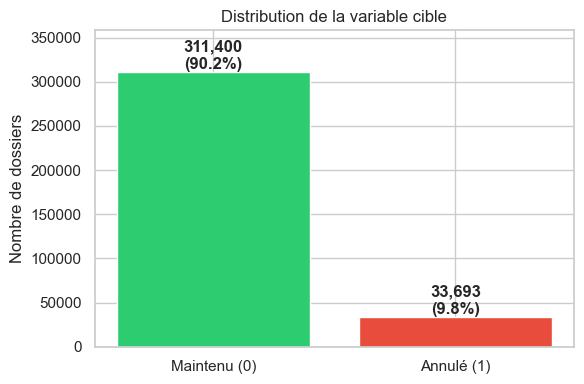

In [10]:
counts = df['y_annulation'].value_counts().sort_index()
pct    = df['y_annulation'].value_counts(normalize=True).sort_index() * 100

print('=== DISTRIBUTION DE LA CIBLE ===')
print(f"  Y=0 (maintenu)  : {counts[0]:,} ({pct[0]:.2f}%)")
print(f"  Y=1 (annulé)    : {counts[1]:,} ({pct[1]:.2f}%)")
print(f"\n  Ratio de déséquilibre : 1 annulation pour {counts[0]/counts[1]:.1f} maintiens")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Maintenu (0)', 'Annulé (1)'], counts.values, color=[C_MAINT, C_ANNUL])
ax.set_title('Distribution de la variable cible')
ax.set_ylabel('Nombre de dossiers')
for b, v, p in zip(bars, counts.values, pct.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.margins(y=0.15)
plt.tight_layout(); plt.savefig('figures/01_cible.png', dpi=150); plt.show()

## 5. La condition d'annulation (Flex) — variable structurelle clé
On attend un gradient : plus la couverture est forte, plus on annule.

=== TAUX D'ANNULATION PAR CONDITION FLEX ===
                            nb  taux_annul
cond_annulation                           
Booking.com J-60          4297       51.31
Booking.com J-30         13471       50.84
Airbnb Moderate           2588       29.52
Booking.com NANR          7327       21.78
Flexi+                    9104       17.61
Abritel NANR                30       10.00
Flexi                   140121        9.51
Airbnb super strict 30    5266        7.60
Airbnb NANR                303        7.59
Airbnb Super strict 60     191        5.76
NoFlex                   19739        4.46
NoFlex (<J30)           131034        4.35
NA / NR P&V              11622        2.80


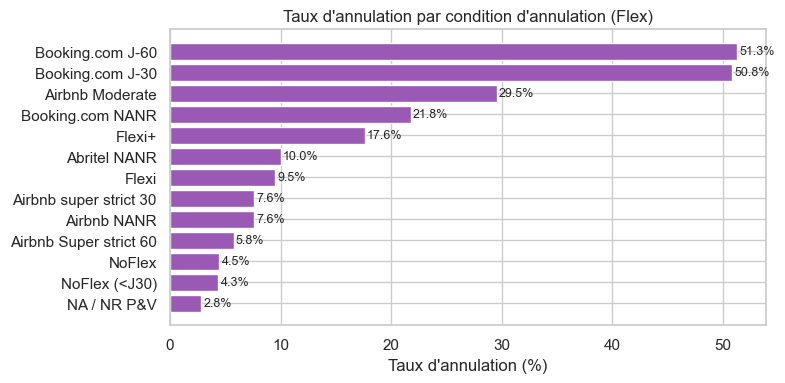

In [11]:
def taux_par(col, min_n=30, top=None):
    """Taux d'annulation + volume par modalité d'une variable catégorielle."""
    g = (df.groupby(col)['y_annulation']
           .agg(nb='count', taux_annul='mean')
           .assign(taux_annul=lambda x: (x['taux_annul']*100).round(2))
           .query('nb >= @min_n')
           .sort_values('taux_annul', ascending=False))
    return g.head(top) if top else g

cond = taux_par('cond_annulation')
print('=== TAUX D\'ANNULATION PAR CONDITION FLEX ===')
print(cond)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cond.index, cond['taux_annul'], color=C_PURP)
ax.invert_yaxis()
ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par condition d\'annulation (Flex)')
for b, v in zip(bars, cond['taux_annul']):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('figures/02_cond_annulation.png', dpi=150); plt.show()

In [12]:
# Synthèse couvert vs non couvert
if 'est_assure_annulation' in df.columns:
    g = (df.groupby('est_assure_annulation')['y_annulation']
           .agg(nb='count', taux='mean'))
    g['taux'] = (g['taux']*100).round(2)
    g.index = ['Non couvert (0)', 'Couvert (1)']
    print('=== COUVERT vs NON COUVERT ===')
    print(g)

=== COUVERT vs NON COUVERT ===
                     nb   taux
Non couvert (0)  195868   9.58
Couvert (1)      149225  10.01


## 6. Le canal de vente

                           nb  taux_annul
canal                                    
Booking                 38282       31.74
Autres                    452       22.57
Site web Parcel          1038       14.64
Ventes sur place         2820       11.88
Site Web affiliés         151        9.93
Sites web Vacansoleil   19775        9.07
Partenaires             57730        8.87
Marques blanches         2071        7.97
Sites web              102178        7.61
Ventes Flash            10589        6.88
Sites web 5C             1721        6.04
CE Global               80756        5.07


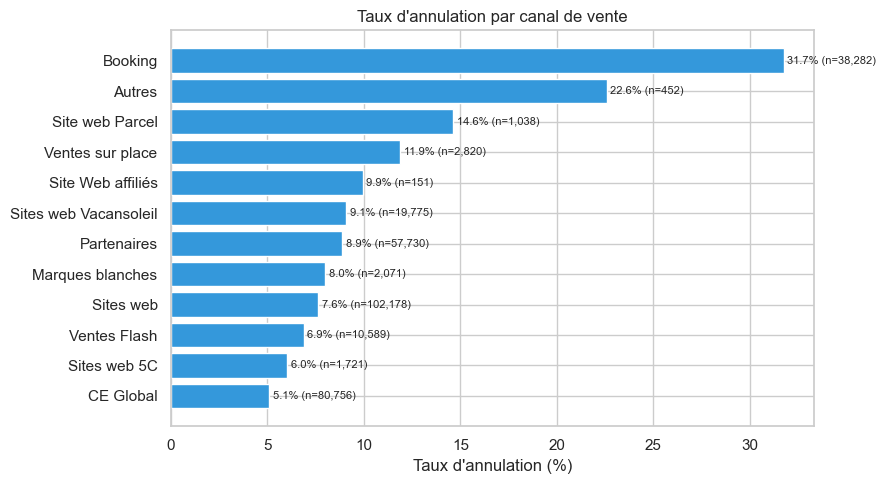

In [13]:
canal = taux_par('canal', top=12)
print(canal)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(canal.index, canal['taux_annul'], color=C_BLUE)
ax.invert_yaxis()
ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par canal de vente')
for b, v, n in zip(bars, canal['taux_annul'], canal['nb']):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}% (n={n:,})', va='center', fontsize=8)
plt.tight_layout(); plt.savefig('figures/03_canal.png', dpi=150); plt.show()

## 7. Saisonnalité & destination

=== PAR THÈME DE STATION ===
                   nb  taux_annul
theme_station                    
montagne        92826       14.18
mer            209993        8.35
ville            3842        8.02
campagne        37564        7.00
paris             868        5.88


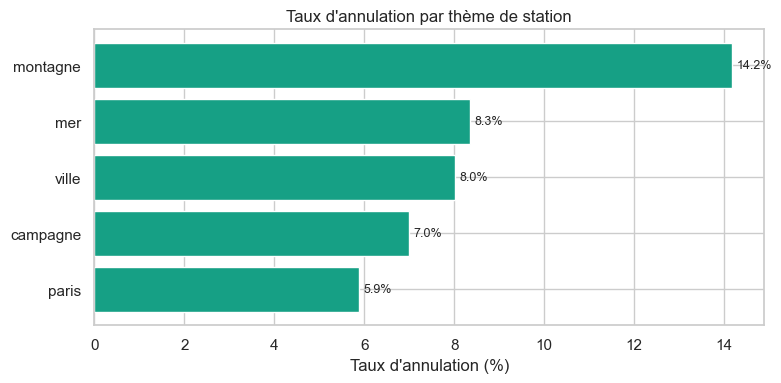

In [14]:
# Thème de station
if 'theme_station' in df.columns:
    theme = taux_par('theme_station', top=10)
    print('=== PAR THÈME DE STATION ===')
    print(theme)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(theme.index, theme['taux_annul'], color='#16a085')
    ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
    ax.set_title('Taux d\'annulation par thème de station')
    for b, v in zip(bars, theme['taux_annul']):
        ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.savefig('figures/04_theme.png', dpi=150); plt.show()

In [15]:
# Période de départ
if 'periode_depart' in df.columns:
    per = taux_par('periode_depart', top=15)
    print('=== PAR PÉRIODE DE DÉPART ===')
    print(per)

=== PAR PÉRIODE DE DÉPART ===
                   nb  taux_annul
periode_depart                   
Vac Nouvel An    8315       19.17
Vac Noel         5676       15.31
Avt Printemps   17446       13.71
Avt Hiver       23756       13.62
Avt Noel         5267       13.35
Vac Hiver       26935       12.54
Avt ÉTÉ         83573        8.98
Vac Toussaint    6095        8.93
Avt Toussaint   31241        8.60
Vac Printemps   39536        7.97
ETE - Aout      54680        7.88
ETE - Juillet   42573        7.81


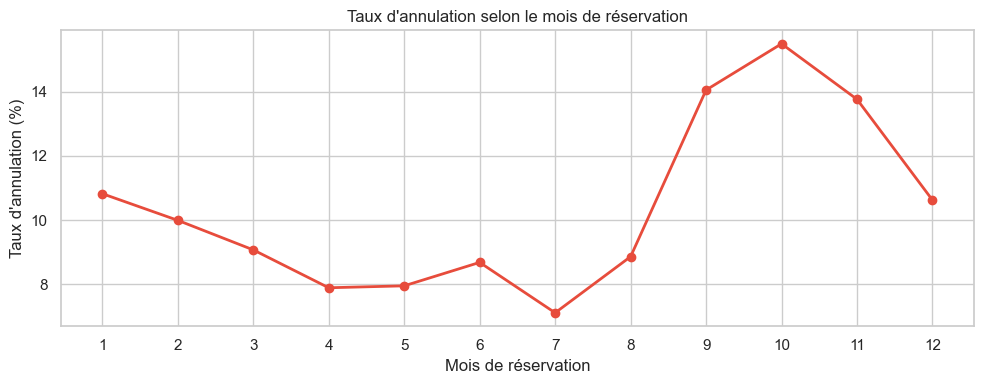

In [16]:
# Mois de réservation (saisonnalité de la prise de décision)
mois = (df.groupby('mois_resa')['y_annulation']
          .agg(nb='count', taux='mean').assign(taux=lambda x:(x['taux']*100).round(2)))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mois.index, mois['taux'], marker='o', color=C_ANNUL, lw=2)
ax.set_xticks(range(1,13))
ax.set_xlabel('Mois de réservation'); ax.set_ylabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation selon le mois de réservation')
plt.tight_layout(); plt.savefig('figures/05_mois.png', dpi=150); plt.show()

## 8. Variables numériques de contexte

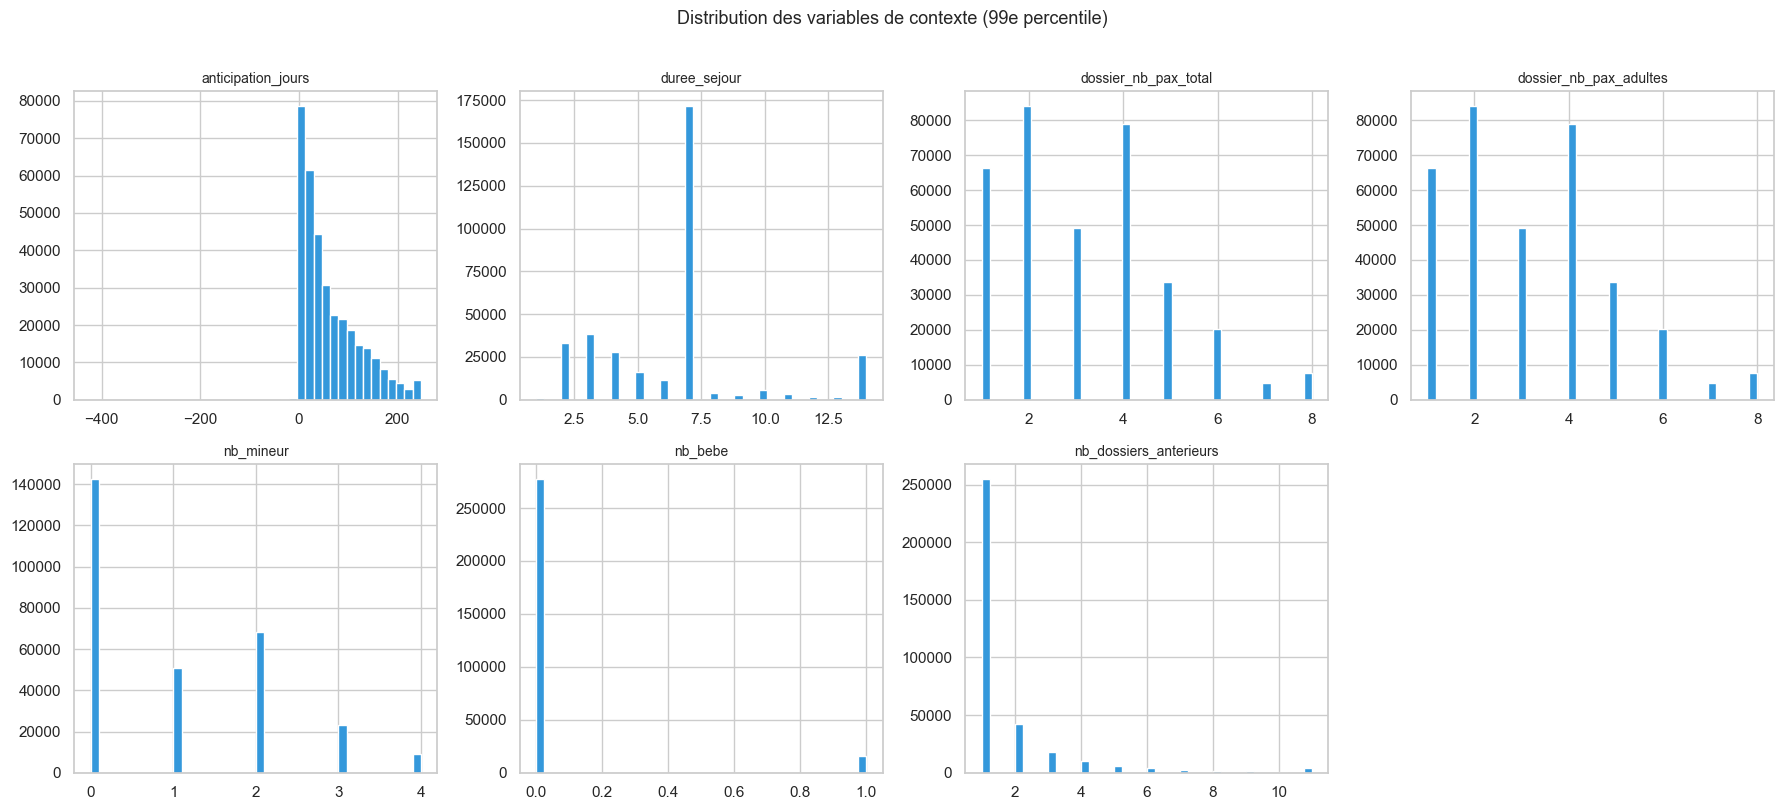

In [17]:
num_context = ['anticipation_jours', 'duree_sejour', 'dossier_nb_pax_total',
               'dossier_nb_pax_adultes', 'nb_mineur', 'nb_bebe',
               'nb_dossiers_anterieurs']
num_context = [c for c in num_context if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.flatten()
for i, col in enumerate(num_context):
    data = df[col].clip(upper=df[col].quantile(0.99))  # coupe les outliers extrêmes pour l'affichage
    axes[i].hist(data, bins=40, color=C_BLUE, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
for j in range(len(num_context), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution des variables de contexte (99e percentile)', y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig('figures/06_num_context.png', dpi=150); plt.show()

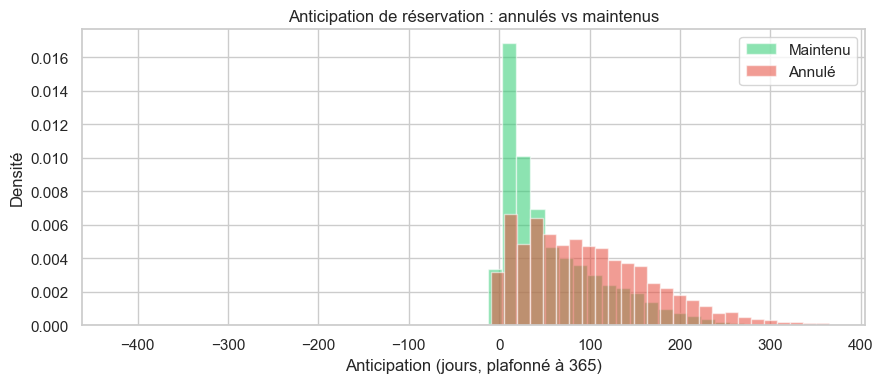

In [18]:
# Anticipation : annulés vs maintenus (un signal souvent fort)
fig, ax = plt.subplots(figsize=(9, 4))
for y, c, lab in [(0, C_MAINT, 'Maintenu'), (1, C_ANNUL, 'Annulé')]:
    d = df.loc[df['y_annulation']==y, 'anticipation_jours'].clip(upper=365)
    ax.hist(d, bins=50, alpha=0.55, color=c, label=lab, density=True)
ax.set_xlabel('Anticipation (jours, plafonné à 365)'); ax.set_ylabel('Densité')
ax.set_title('Anticipation de réservation : annulés vs maintenus')
ax.legend()
plt.tight_layout(); plt.savefig('figures/07_anticipation.png', dpi=150); plt.show()

## 9. Couverture email (CRM) — la contrainte Batch
Rappel : Batch ne couvre que ~7 mois, donc une minorité de dossiers a un historique email.

In [19]:
if 'est_dans_crm' in df.columns:
    n_crm = int(df['est_dans_crm'].sum())
    pct_crm = df['est_dans_crm'].mean()*100
    print(f"Dossiers AVEC historique email : {n_crm:,} ({pct_crm:.1f}%)")
    print(f"Dossiers SANS historique email : {len(df)-n_crm:,} ({100-pct_crm:.1f}%)")

# Distribution du segment d'engagement
seg = df['segment_email'].value_counts()
print('\n=== RÉPARTITION DES SEGMENTS EMAIL ===')
print(seg)

Dossiers AVEC historique email : 31,028 (9.0%)
Dossiers SANS historique email : 314,065 (91.0%)

=== RÉPARTITION DES SEGMENTS EMAIL ===
segment_email
inactif              326782
ouvreur_seulement     10034
peu_engage             3111
engage                 2443
tres_engage            2300
desabonne               423
Name: count, dtype: int64


                       nb  taux_annul
segment_email                        
inactif            326782        9.97
tres_engage          2300        7.04
peu_engage           3111        6.65
engage               2443        6.63
ouvreur_seulement   10034        5.59
desabonne             423        4.96


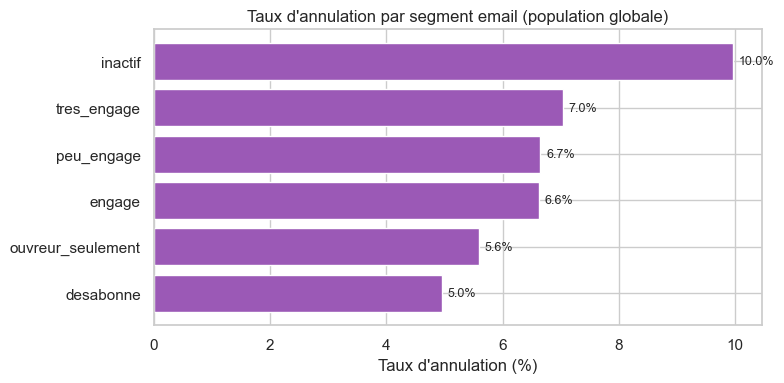

In [20]:
# Taux d'annulation par segment email (toute la population)
seg_taux = taux_par('segment_email')
print(seg_taux)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(seg_taux.index, seg_taux['taux_annul'], color=C_PURP)
ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
ax.set_title('Taux d\'annulation par segment email (population globale)')
for b, v in zip(bars, seg_taux['taux_annul']):
    ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('figures/08_segment_global.png', dpi=150); plt.show()

## 10. ★ ANALYSE CENTRALE : l'email chez les clients NON couverts
C'est le cœur du mémoire : chez ceux qui perdent leur argent en annulant (non assurés), l'engagement email discrimine-t-il l'annulation ?

Population non couverte : 195,868 dossiers (taux annul. global 9.58%)

=== TAUX D'ANNULATION PAR SEGMENT EMAIL (NON COUVERTS) ===
                       nb  taux
segment_email                  
inactif            185586  9.93
peu_engage           1727  4.05
tres_engage          1204  3.24
ouvreur_seulement    5707  3.17
engage               1382  2.60
desabonne             262  2.29


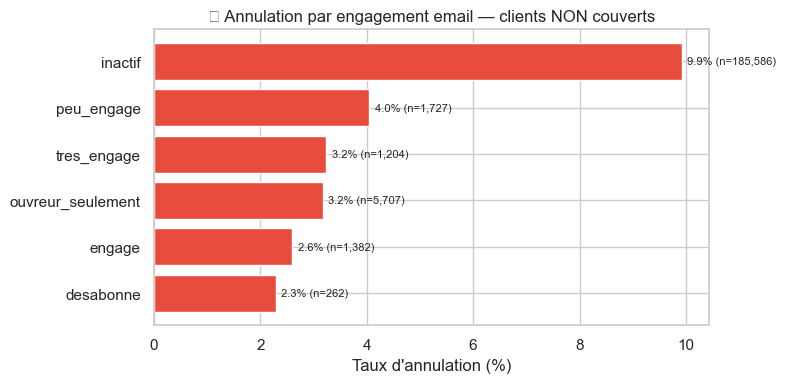

In [21]:
if 'est_assure_annulation' in df.columns:
    non_couverts = df[df['est_assure_annulation'] == 0]
    print(f'Population non couverte : {len(non_couverts):,} dossiers '
          f'(taux annul. global {non_couverts["y_annulation"].mean()*100:.2f}%)\n')

    g = (non_couverts.groupby('segment_email')['y_annulation']
                     .agg(nb='count', taux='mean')
                     .assign(taux=lambda x:(x['taux']*100).round(2))
                     .sort_values('taux', ascending=False))
    print('=== TAUX D\'ANNULATION PAR SEGMENT EMAIL (NON COUVERTS) ===')
    print(g)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(g.index, g['taux'], color=C_ANNUL)
    ax.invert_yaxis(); ax.set_xlabel('Taux d\'annulation (%)')
    ax.set_title('★ Annulation par engagement email — clients NON couverts')
    for b, v, n in zip(bars, g['taux'], g['nb']):
        ax.text(v+0.1, b.get_y()+b.get_height()/2, f'{v:.1f}% (n={n:,})', va='center', fontsize=8)
    plt.tight_layout(); plt.savefig('figures/09_email_non_couverts.png', dpi=150); plt.show()

## 11. Matrice de corrélation (variables numériques)

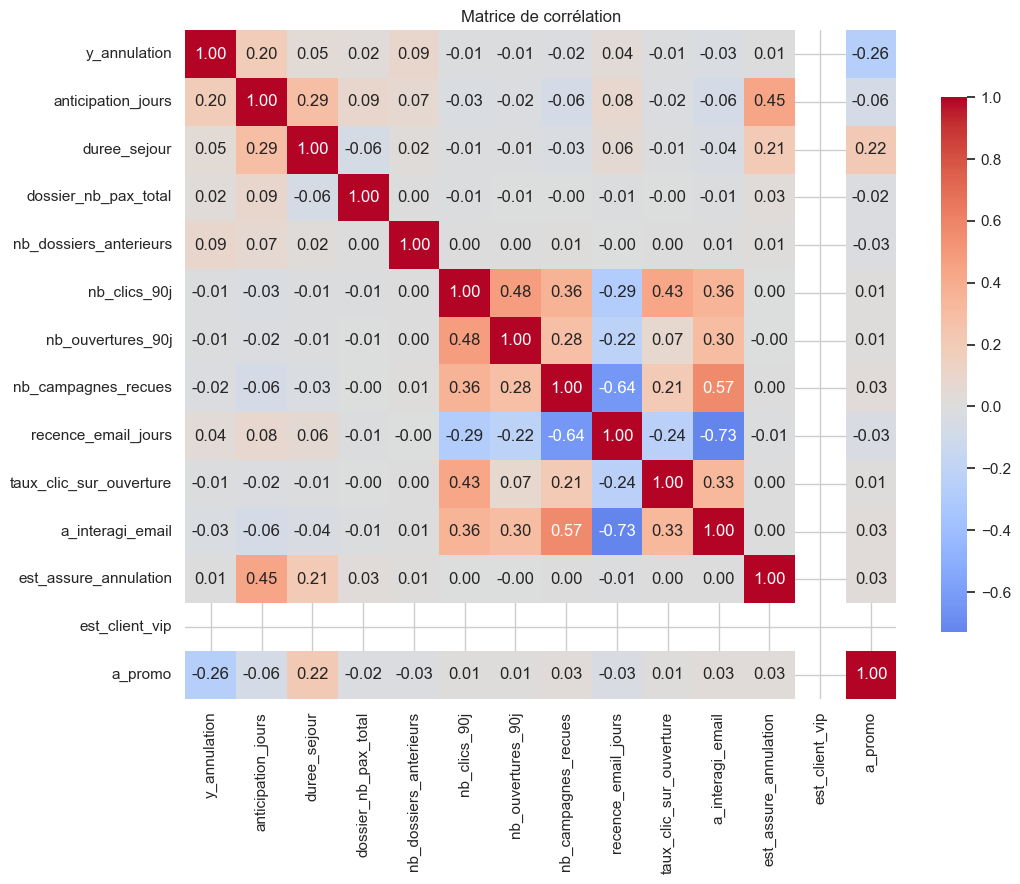

In [22]:
corr_cols = ['y_annulation', 'anticipation_jours', 'duree_sejour',
             'dossier_nb_pax_total', 'nb_dossiers_anterieurs',
             'nb_clics_90j', 'nb_ouvertures_90j', 'nb_campagnes_recues',
             'recence_email_jours', 'taux_clic_sur_ouverture', 'a_interagi_email',
             'est_assure_annulation', 'est_client_vip', 'a_promo']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=False, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout(); plt.savefig('figures/10_correlation.png', dpi=150); plt.show()

In [23]:
# Corrélations avec la cible, triées
corr_cible = df[corr_cols].corr()['y_annulation'].drop('y_annulation').sort_values(key=abs, ascending=False)
print('=== CORRÉLATION (Pearson) AVEC LA CIBLE ===')
print(corr_cible.round(3))

=== CORRÉLATION (Pearson) AVEC LA CIBLE ===
a_promo                   -0.256
anticipation_jours         0.195
nb_dossiers_anterieurs     0.092
duree_sejour               0.046
recence_email_jours        0.036
a_interagi_email          -0.028
dossier_nb_pax_total       0.025
nb_campagnes_recues       -0.023
nb_ouvertures_90j         -0.010
nb_clics_90j              -0.009
est_assure_annulation      0.007
taux_clic_sur_ouverture   -0.007
est_client_vip               NaN
Name: y_annulation, dtype: float64


## 12. Synthèse EDA

In [24]:
print('='*55)
print('  SYNTHÈSE EDA — DATASET ANNULATION')
print('='*55)
print(f'  Dossiers          : {len(df):,}')
print(f'  Variables         : {df.shape[1]}')
print(f'  Taux annulation   : {df["y_annulation"].mean()*100:.2f}%')
if 'est_dans_crm' in df.columns:
    print(f'  Couverture email  : {df["est_dans_crm"].mean()*100:.1f}%')
print()
print('  À retenir pour la modélisation :')
print('   - Déséquilibre modéré -> class_weight / SMOTE')
print('   - cond_annulation & canal = signaux structurels forts')
print('   - Email : signal réel mais sur une minorité (sous-ensemble CRM)')
print('   - Stratégie 2 temps : modèle global + focus est_dans_crm=1')
print('  Graphiques sauvegardés dans ./figures/')
print('='*55)

  SYNTHÈSE EDA — DATASET ANNULATION
  Dossiers          : 345,093
  Variables         : 40
  Taux annulation   : 9.76%
  Couverture email  : 9.0%

  À retenir pour la modélisation :
   - Déséquilibre modéré -> class_weight / SMOTE
   - cond_annulation & canal = signaux structurels forts
   - Email : signal réel mais sur une minorité (sous-ensemble CRM)
   - Stratégie 2 temps : modèle global + focus est_dans_crm=1
  Graphiques sauvegardés dans ./figures/
